In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression , Lasso ,Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # Needed for HistGB
from sklearn.ensemble import (RandomForestRegressor,ExtraTreesRegressor,BaggingRegressor,
                              AdaBoostRegressor ,GradientBoostingRegressor,HistGradientBoostingRegressor
                              , VotingRegressor,StackingRegressor)
#import xgboost as xgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
#import lightgbm as lgb
from lightgbm import LGBMRegressor

In [3]:

df =pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.92400
1,18.0,male,33.770,1.0,no,southeast,1725.55230
2,28.0,male,33.000,3.0,no,southeast,4449.46200
3,33.0,male,22.705,0.0,no,northwest,21984.47061
4,32.0,male,28.880,0.0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1296 non-null   float64
 1   sex       1329 non-null   object 
 2   bmi       1296 non-null   float64
 3   children  1314 non-null   float64
 4   smoker    1305 non-null   object 
 5   region    1054 non-null   object 
 6   charges   1314 non-null   float64
dtypes: float64(4), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1296.000000,1296.000000,1314.000000,1314.000000
mean,39.225309,30.655197,1.092846,13259.233168
std,14.034162,6.117612,1.205684,12136.291497
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4724.369462
50%,39.000000,30.380000,1.000000,9289.083100
75%,51.000000,34.600000,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns:", list(num_cols))
print("Categorical Columns:", list(cat_cols))

Numerical Columns: ['age', 'bmi', 'children', 'charges']
Categorical Columns: ['sex', 'smoker', 'region']


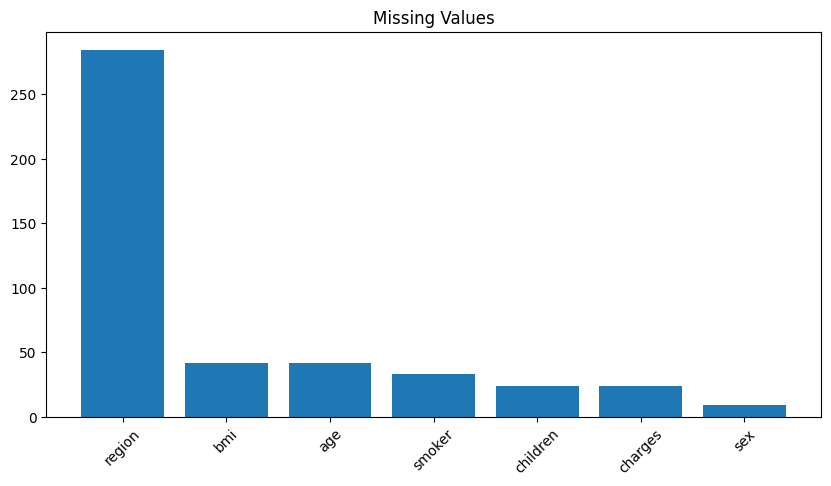

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

if len(missing) > 0:
    plt.figure(figsize=(10,5))
    plt.bar(missing.index, missing.values)
    plt.xticks(rotation=45)
    plt.title("Missing Values")
    plt.show()

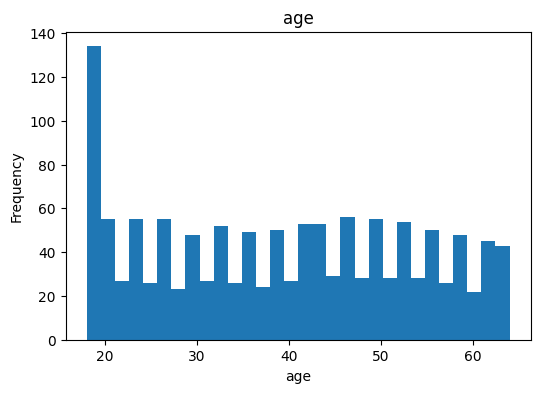

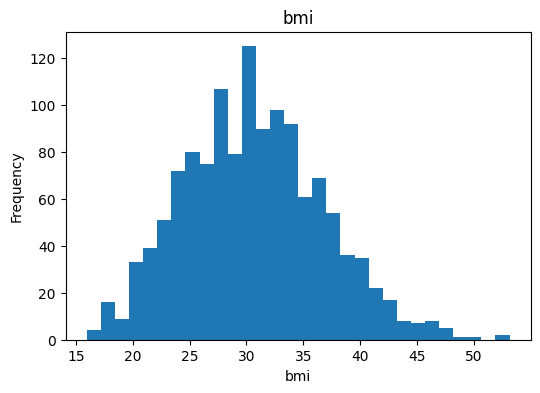

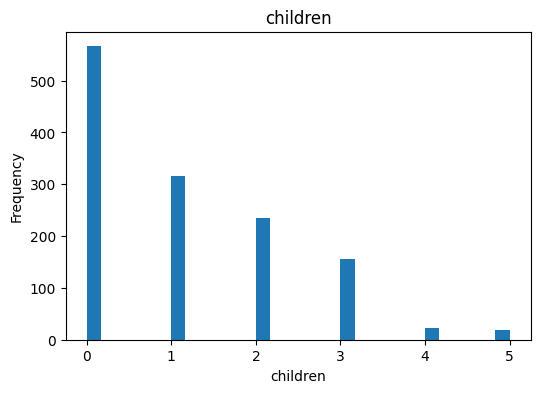

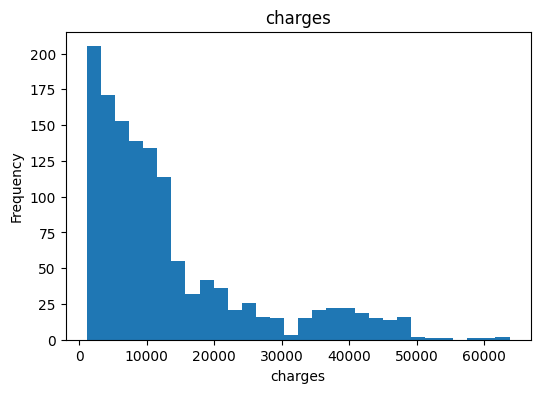

In [9]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

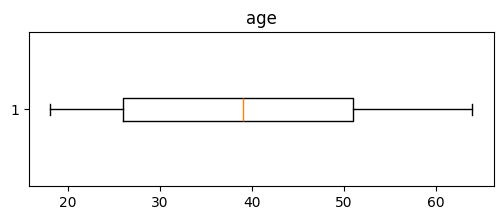

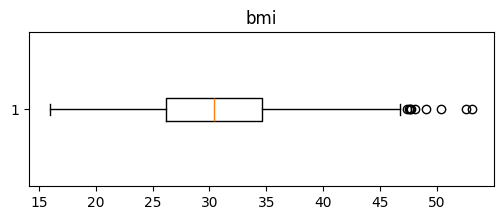

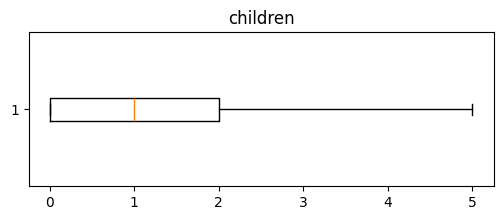

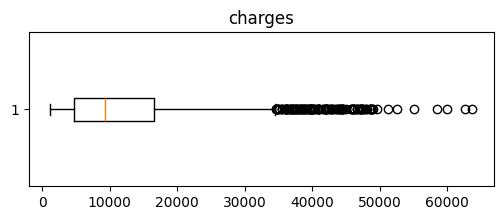

In [10]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

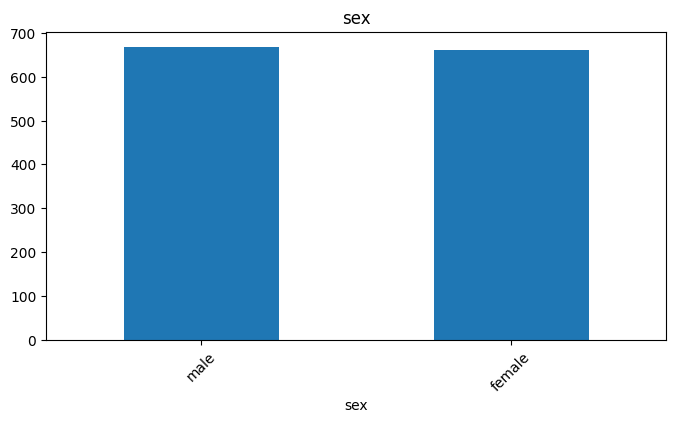

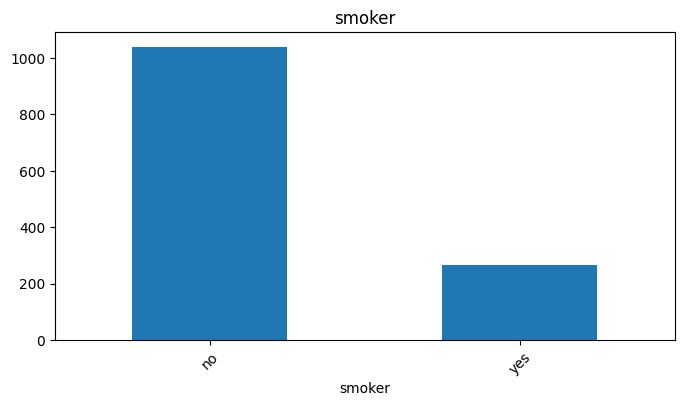

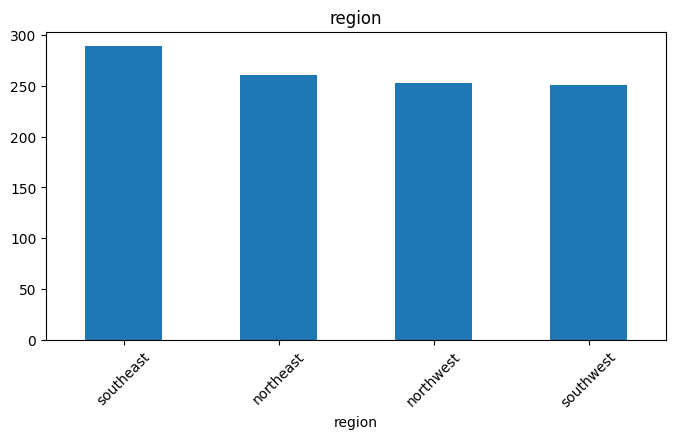

In [11]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

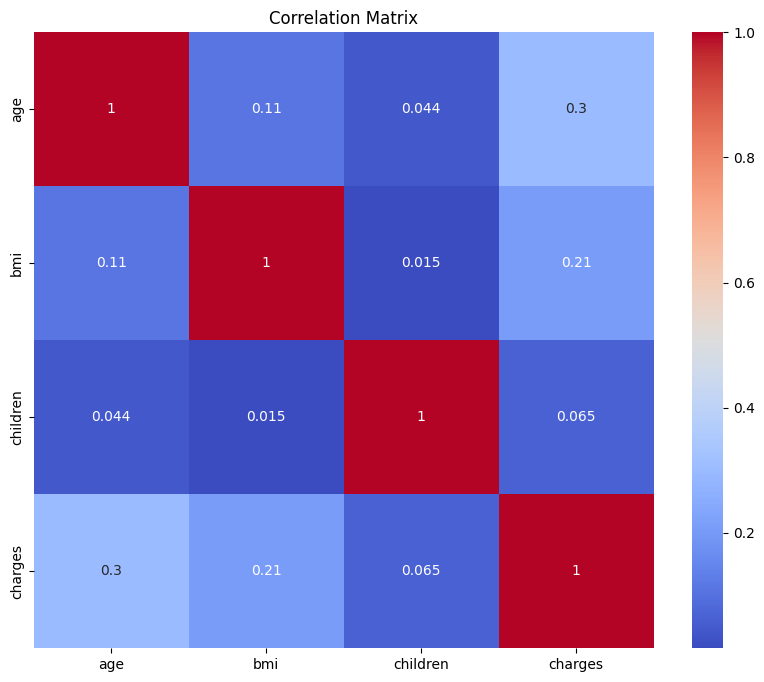

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

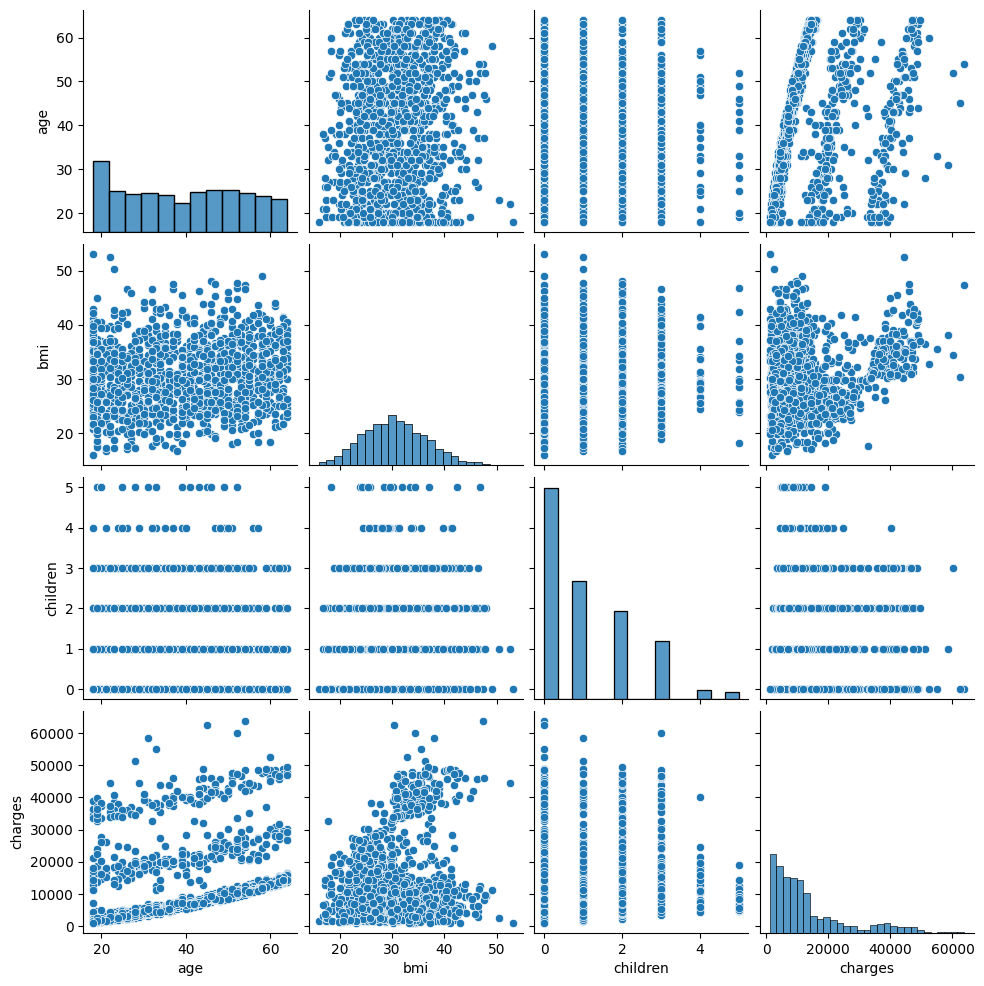

In [13]:
sns.pairplot(df[num_cols[:5]])
plt.show()

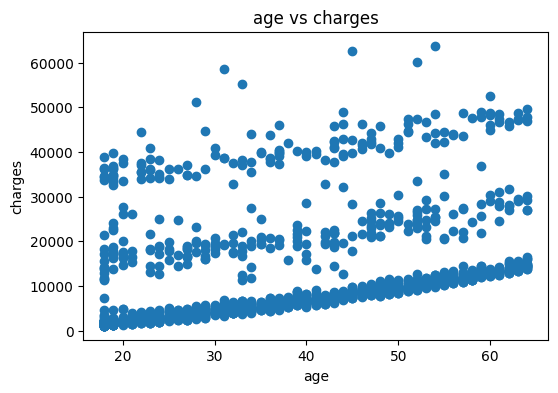

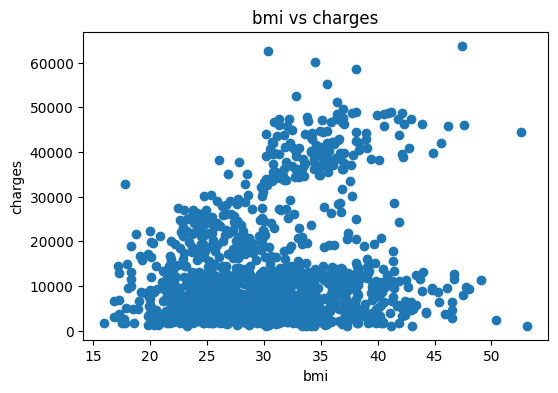

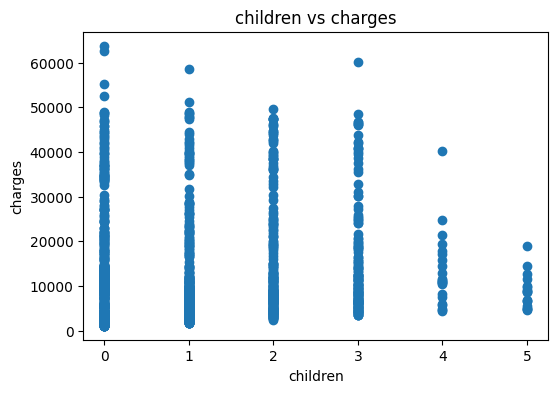

In [14]:
target = "charges"   

for col in num_cols:
    if col != target:
        plt.figure(figsize=(6,4))
        plt.scatter(df[col], df[target])
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f"{col} vs {target}")
        plt.show()

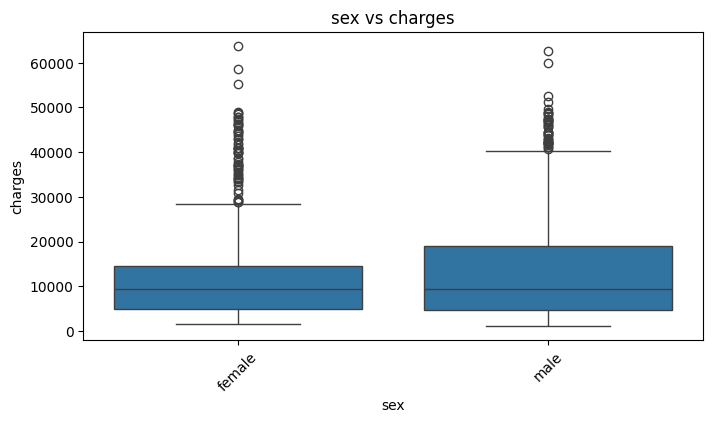

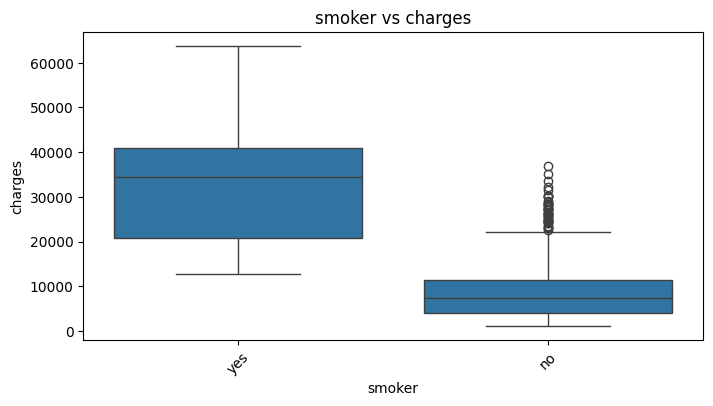

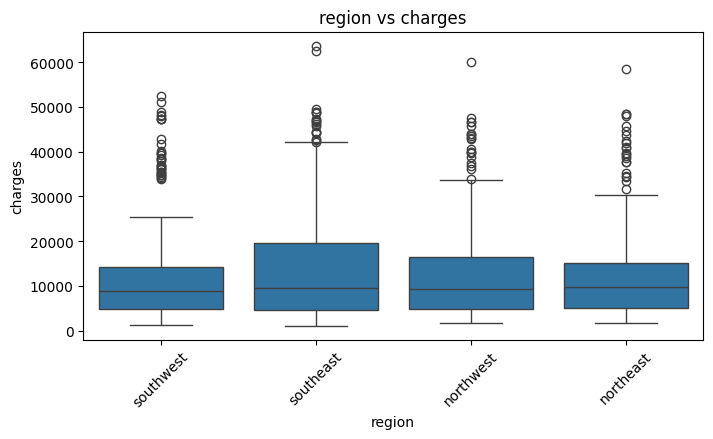

In [15]:
target = "charges"

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], y=df[target])
    plt.xticks(rotation=45)
    plt.title(f"{col} vs {target}")
    plt.show()

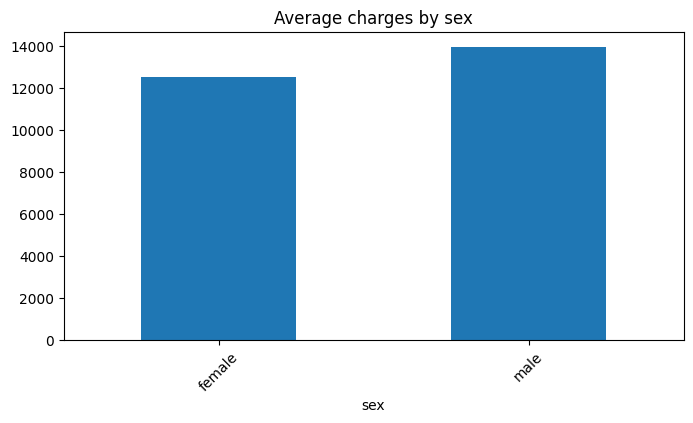

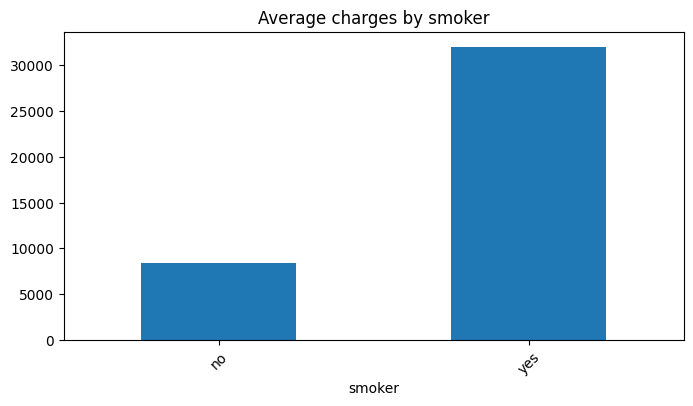

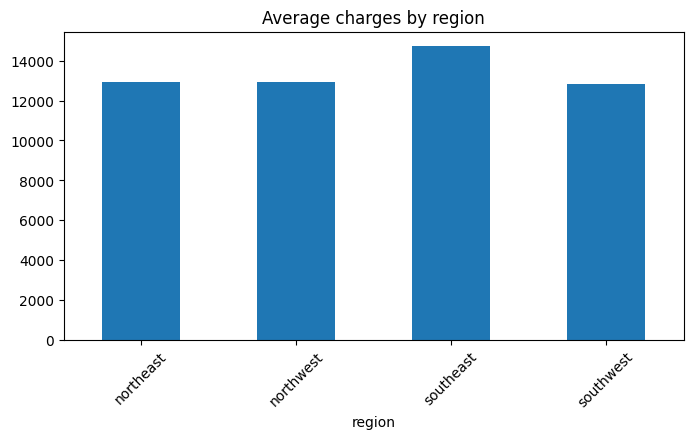

In [16]:
target = "charges"

for col in cat_cols:
    plt.figure(figsize=(8,4))
    df.groupby(col)[target].mean().plot(kind="bar")
    plt.title(f"Average {target} by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [17]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [18]:
df.dropna(subset="charges", inplace= True)

In [19]:
x = df.drop("charges", axis=1)
y= df["charges"]

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.impute import SimpleImputer
impeter= SimpleImputer(strategy='most_frequent')
columns=["age", "sex","bmi","children","smoker","region"]
for col in columns:
    x_train[col]=impeter.fit_transform(x_train[[col]]).flatten()
    x_test[col]=impeter.transform(x_test[[col]]).flatten()


In [22]:
x_train = x_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

x_test = x_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [23]:
from sklearn.preprocessing import LabelEncoder

columns = ["smoker", "region", "sex"]

for col in columns:
    lb = LabelEncoder()

    x_train[col] = lb.fit_transform(x_train[col])
    x_test[col] = lb.transform(x_test[col])

In [24]:
from sklearn.preprocessing import MinMaxScaler
columns = ["region","smoker", "children","bmi","age","sex"]
sc=MinMaxScaler()
for col in columns:
    x_train[col]=sc.fit_transform(x_train[[col]])
    x_test[col]=sc.transform(x_test[[col]])

In [26]:
models ={
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "KNN":KNeighborsRegressor(n_neighbors=5,metric='minkowski',p=1), #  minkowski , euclidean , manhattan
    "SVM":SVR(kernel='linear', C=100, gamma=1), # kernel='rbf' / kernel='poly', degree=4 / kernel='sigmoid
    "Decision Tree":DecisionTreeRegressor(criterion='squared_error',max_depth=10), #{"squared_error", "friedman_mse", "absolute_error", "poisson"}
    "Random Forest":RandomForestRegressor(n_estimators=50,criterion='squared_error',max_depth=10), #{"squared_error", "friedman_mse", "absolute_error", "poisson"}
    "ExtraTrees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "Bagging": BaggingRegressor(estimator=DecisionTreeRegressor(criterion='squared_error',max_depth=10),n_estimators=50, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=15, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0),
    "CatBoost": CatBoostRegressor(verbose=0, iterations=100, learning_rate=0.1, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

In [27]:
# Metrics function
def regression_metrics(model, X, y_actual):
    y_pred = model.predict(X)
    MAE = mean_absolute_error(y_actual, y_pred)
    MSE = mean_squared_error(y_actual, y_pred)
    RMSE = np.sqrt(MSE)
    R2 = r2_score(y_actual, y_pred)
    return MAE, MSE, RMSE, R2

In [32]:
errors=[]
for model_name , model in models.items():
    model.fit(x_train,y_train)
    MAE_Train = mean_absolute_error(y_train,model.predict(x_train))
    MAE_Test  =  mean_absolute_error(y_test,model.predict(x_test))

    MSE_Train = mean_squared_error(y_train,model.predict(x_train))
    MSE_Test  =  mean_squared_error(y_test,model.predict(x_test))


    R_Train = r2_score(y_train,model.predict(x_train))
    R_Test  =  r2_score(y_test,model.predict(x_test))
    
    errors.append([MAE_Train,MSE_Train,R_Train,MAE_Test,MSE_Test,R_Test])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000800 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 315
[LightGBM] [Info] Number of data points in the train set: 1051, number of used features: 6
[LightGBM] [Info] Start training from score 13108.597310


In [33]:
pd.DataFrame(errors,columns=["MAE_Train","MSE_Train","R_Train","MAE_Test","MSE_Test","R_Test"],index=models.keys())

,MAE_Train,MSE_Train,R_Train,MAE_Test,MSE_Test,R_Test
Linear Regression,4393.991797,4.019413e+07,0.717740,4614.572402,4.362439e+07,0.736903
Lasso,4393.266825,4.019421e+07,0.717740,4613.817537,4.362956e+07,0.736872
Ridge,4390.480123,4.020177e+07,0.717687,4616.130384,4.371740e+07,0.736342
KNN,3020.414718,2.458730e+07,0.827338,3757.456603,3.517792e+07,0.787843
SVM,4109.953787,7.112202e+07,0.500552,4572.280561,8.523745e+07,0.485936
Decision Tree,660.113640,4.184089e+06,0.970618,3079.202158,3.934913e+07,0.762687
Random Forest,1440.567753,6.727966e+06,0.952753,3032.704632,2.868204e+07,0.827020
ExtraTrees,74.885633,9.610619e+05,0.993251,3211.627785,3.248732e+07,0.804070
Bagging,1410.777842,6.516054e+06,0.954242,2896.702994,2.757862e+07,0.833674
AdaBoost,4247.892060,2.997005e+07,0.789538,4400.377208,3.290146e+07,0.801572
